# 202 — multimodalidad · bloque conjunto ξ₁..ξ₄ · E_04 evaluación

Predicción a h=1 sobre train y test, banda por cuantiles y las diez métricas sobre la ventana móvil contra la curva suavizada. Persiste `banda_funcional_psbp_mv.npz`.

In [1]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
RAIZ = Path.cwd().resolve().parent
sys.path.insert(0, str(RAIZ))
from mv_psbp.pipeline import *
from mv_psbp import datos, convergencia, evaluacion, comparacion
pd.set_option("display.width", 200)


In [2]:
# [CONFIG]
ESC       = "202"           # escenario de la corrida viva (se lee de fuera, no se modifica)
EID       = "mvb_escenario_202_chungEscX_1_r01_K10"
EID_MV    = "mv_escenario_202_chungEscX_1_r01_K10"       # conjunto completo (K coordenadas), tercer competidor en E_05
DOMINIO   = "simulaciones"
BLOQUE    = (0, 1, 2, 3)         # coordenadas del bloque conjunto (scores activos del generador)
N_CHAINS  = 3
LIMPIAR   = False


In [3]:
paths = paths_de(EID, DOMINIO)
P = evaluacion.paso04(paths, N_CHAINS, thin=4)
print("muestras de curva por origen:", P["S"])
display(P["resumen"].round(4))
display(pd.read_csv(paths["out_report"] / "56b_agregado_test.csv", index_col=0).T.round(4))

muestras de curva por origen: 3375


,metrica,bloque,minimo,maximo,promedio
0,mae_f,train,0.5556,0.7553,0.6509
1,mae_f,test,0.5588,0.7740,0.6812
2,rmse_f,train,0.7105,0.9490,0.8220
3,rmse_f,test,0.7001,0.9880,0.8591
4,linf_medio,train,1.3168,1.7603,1.5212
5,linf_medio,test,1.3433,1.7760,1.5769
6,linf_max,train,2.1698,3.7858,2.7981
7,linf_max,test,1.9542,3.9554,3.0029
8,mpiw,train,3.2241,3.3819,3.2975
9,mpiw,test,3.2346,3.4735,3.3207


,mae_f,rmse_f,l2_medio,razon_agregacion,linf_max,linf_medio,q95_abs_medio,razon_linf_l1_media,argmax_tau_peor,argmax_origen_peor,n,winkler,picp,mpiw,picp_simultaneo
0,0.6793,0.8579,0.811,0.9454,3.9554,1.5795,1.4792,2.3733,0.8243,203.0,300.0,3.9976,0.9458,3.3264,0.5933


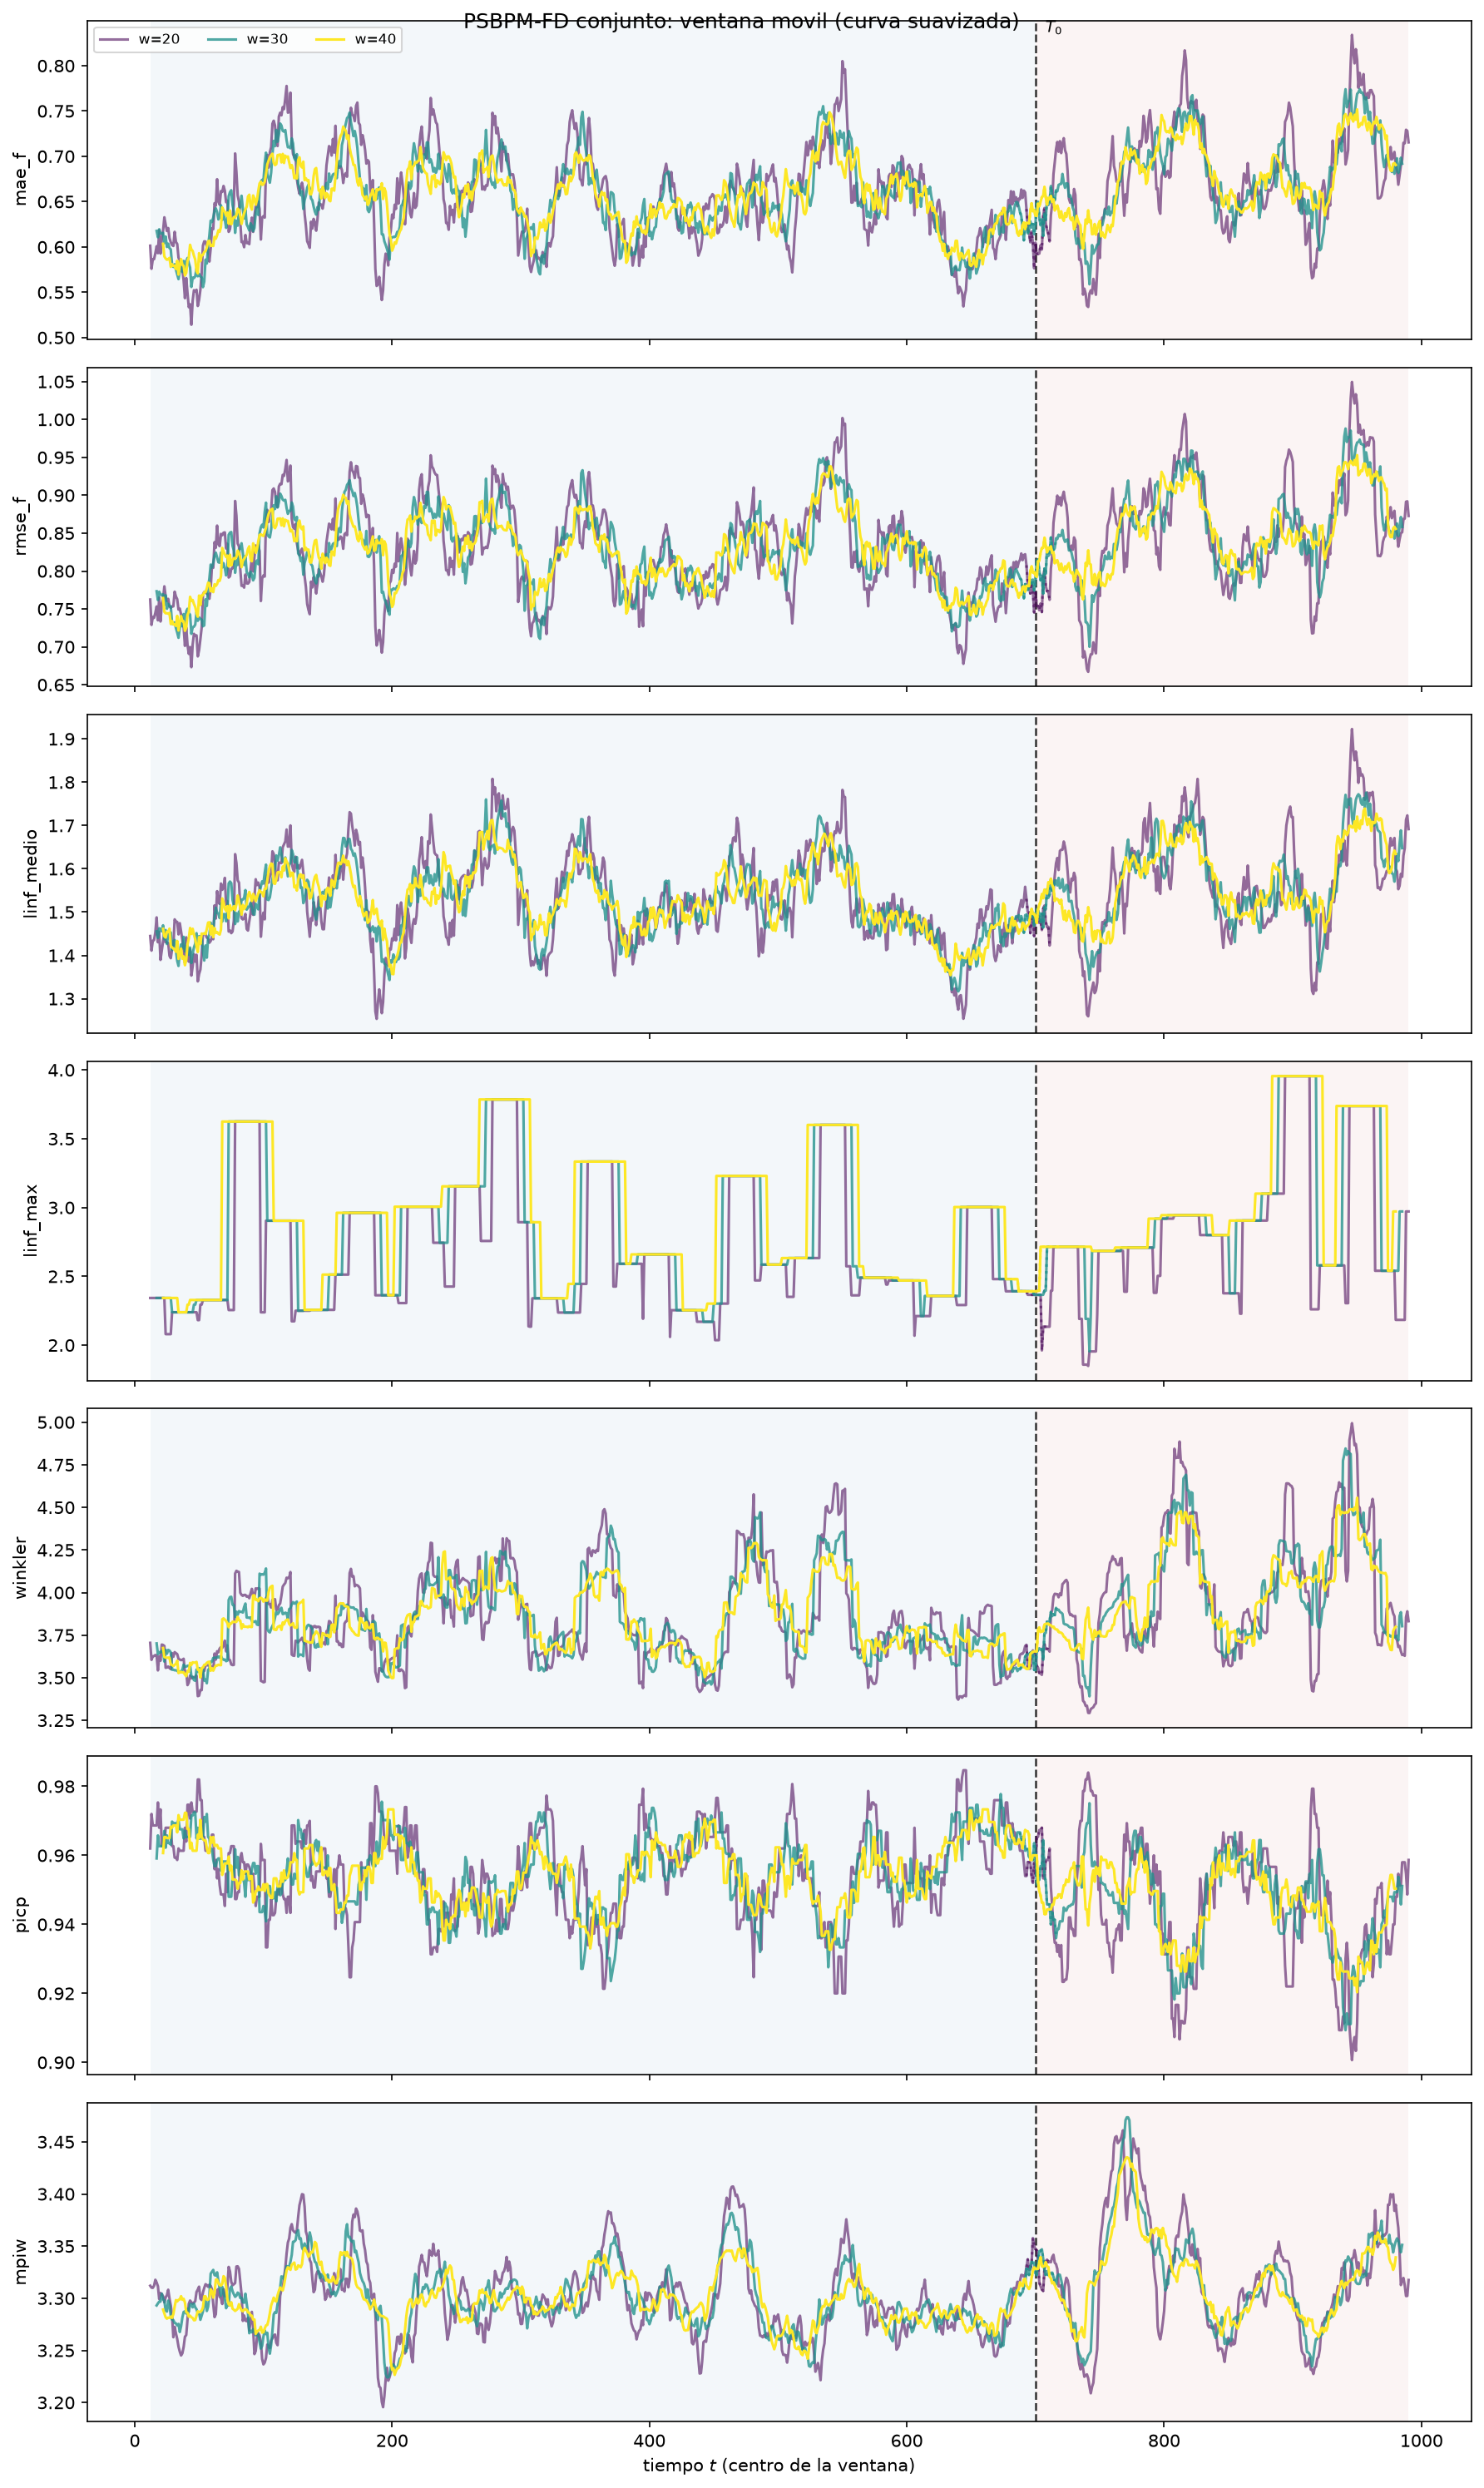

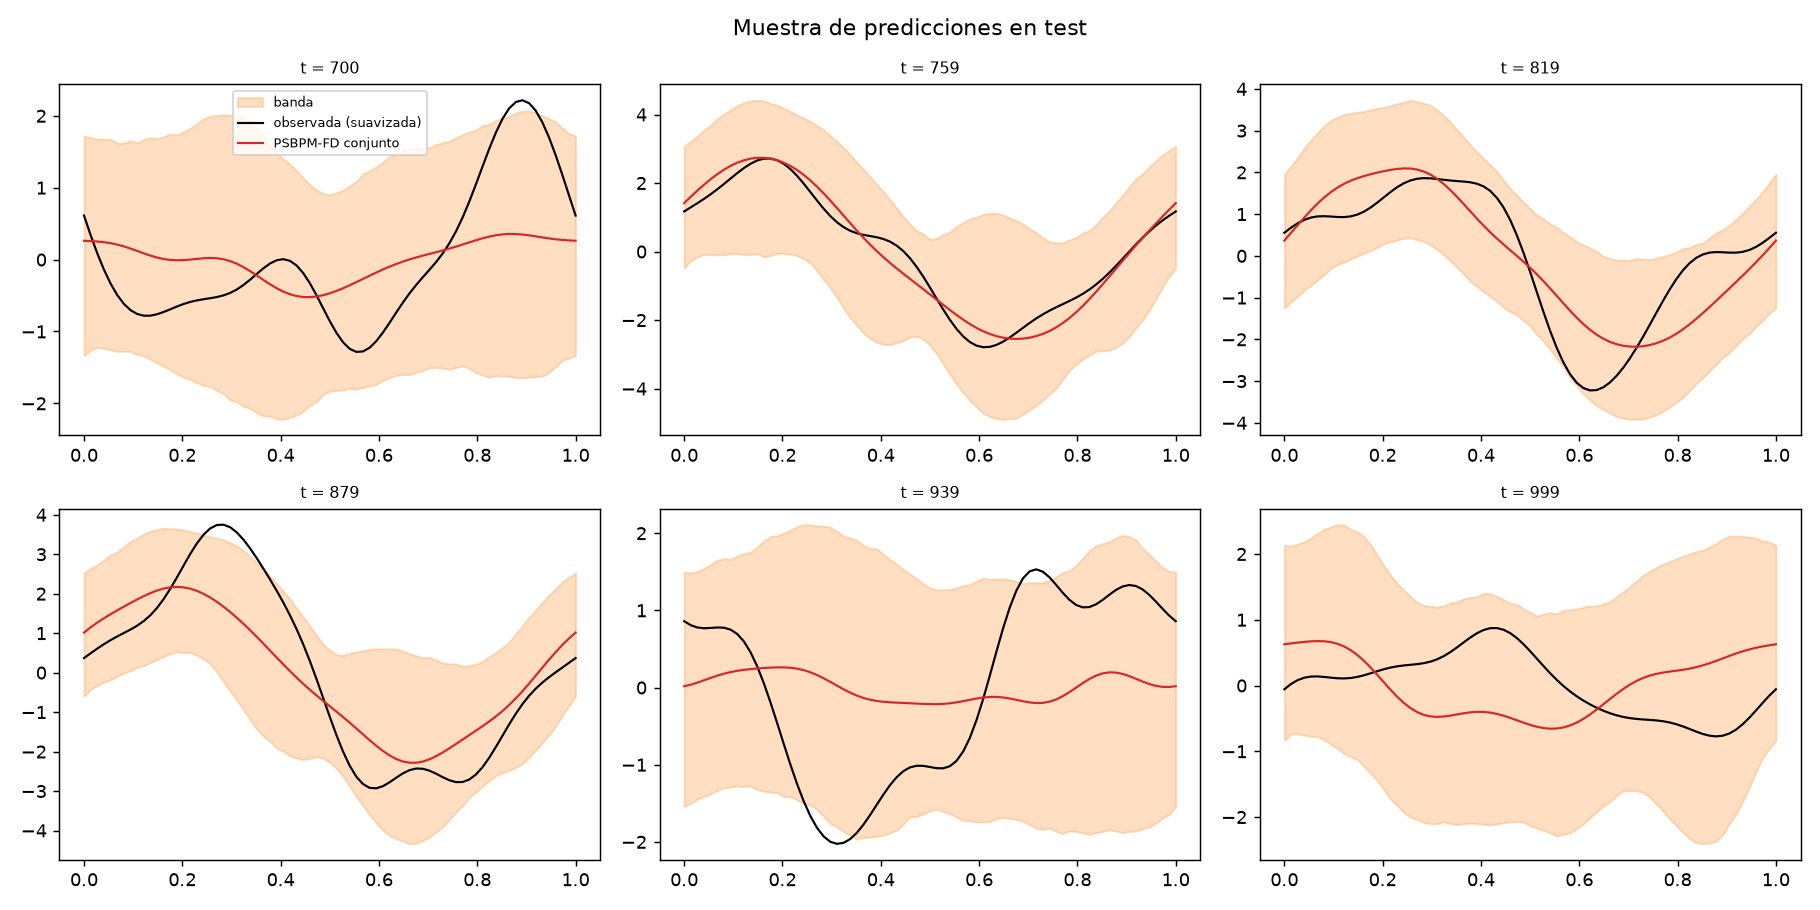

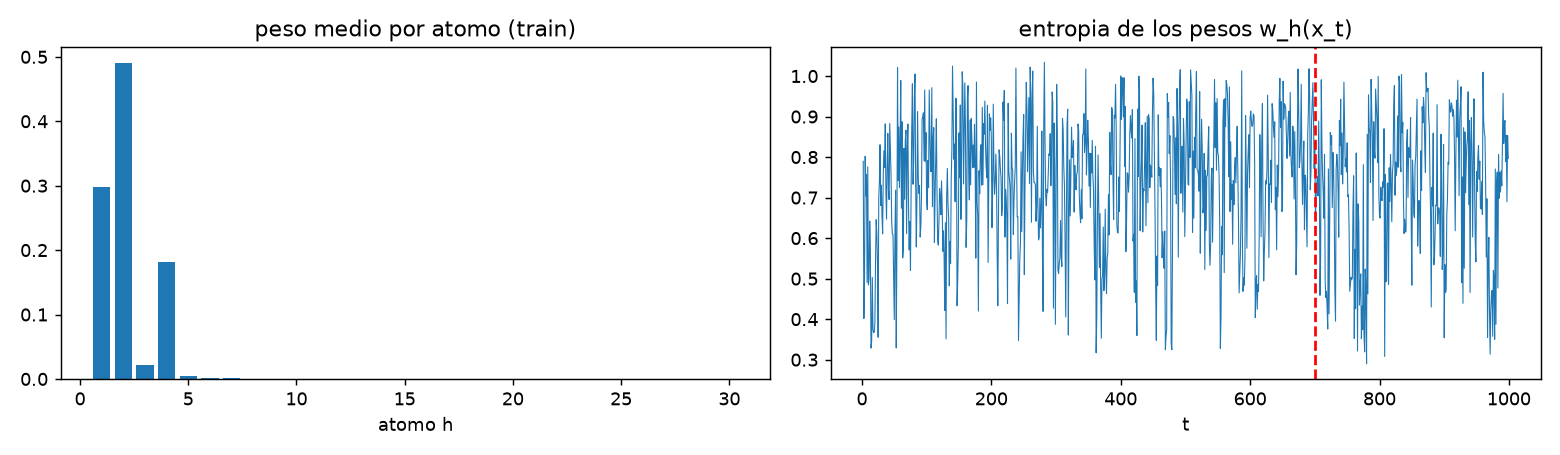

In [4]:
for f in ("55_ventana_movil.png", "57_muestra_predicciones.png", "58_ocupacion_mezcla.png"):
    display(Image(filename=str(paths["out_report"] / f)))